In [33]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
path = "data/"

In [35]:
orders = pd.read_csv(path + "olist_orders_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
sellers = pd.read_csv(path + "olist_sellers_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
category_translation = pd.read_csv(path + "product_category_name_translation.csv")

In [36]:
print("All files loaded successfully")
print("Orders.shape:",orders.shape)
print("Order items shape:",order_items)

All files loaded successfully
Orders.shape: (99441, 8)
Order items shape:                                 order_id  order_item_id  \
0       00010242fe8c5a6d1ba2dd792cb16214              1   
1       00018f77f2f0320c557190d7a144bdd3              1   
2       000229ec398224ef6ca0657da4fc703e              1   
3       00024acbcdf0a6daa1e931b038114c75              1   
4       00042b26cf59d7ce69dfabb4e55b4fd9              1   
...                                  ...            ...   
112645  fffc94f6ce00a00581880bf54a75a037              1   
112646  fffcd46ef2263f404302a634eb57f7eb              1   
112647  fffce4705a9662cd70adb13d4a31832d              1   
112648  fffe18544ffabc95dfada21779c9644f              1   
112649  fffe41c64501cc87c801fd61db3f6244              1   

                              product_id                         seller_id  \
0       4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1       e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c6143

In [37]:
print("\n---Orders sample---")
print(orders.head())


---Orders sample---
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31

In [38]:
print("\n---Order Items sample---")
print(order_items.head())


---Order Items sample---
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3  2018-08-15 10:1

In [39]:
df = order_items.merge(orders, on="order_id", how="left")
df = df.merge(customers, on="customer_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(sellers, on="seller_id", how="left")
df = df.merge(category_translation, on="product_category_name", how="left")

In [40]:
payments_agg = payments.groupby("order_id").agg(
    total_payment=("payment_value", "sum"),
    payment_type=("payment_type", "first")
).reset_index()
df = df.merge(payments_agg, on="order_id", how="left")

In [41]:
reviews_unique = reviews.drop_duplicates(subset="order_id")[["order_id", "review_score"]]
df = df.merge(reviews_unique, on="order_id", how="left")

In [42]:
print(df.shape)
print(df.columns.tolist())

(112650, 33)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name_english', 'total_payment', 'payment_type', 'review_score']


In [43]:
# Convert date columns to datetime
date_cols = ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Drop rows with no purchase timestamp
df = df.dropna(subset=["order_purchase_timestamp"])

# Save cleaned master file
df.to_csv(path + "ecommerce_master_cleaned.csv", index=False)
print("Saved! Final shape:", df.shape)

Saved! Final shape: (112650, 33)


In [44]:
print("--- Revenue by Category (Top 10) ---")
print(df.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False).head(10))

print("\n--- Monthly Revenue Trend ---")
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M")
print(df.groupby("order_month")["price"].sum())

print("\n--- Average Order Value ---")
print(f"AOV: R$ {df.groupby('order_id')['price'].sum().mean():.2f}")

print("\n--- Top 10 States by Revenue ---")
print(df.groupby("customer_state")["price"].sum().sort_values(ascending=False).head(10))

--- Revenue by Category (Top 10) ---
product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

--- Monthly Revenue Trend ---
order_month
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686

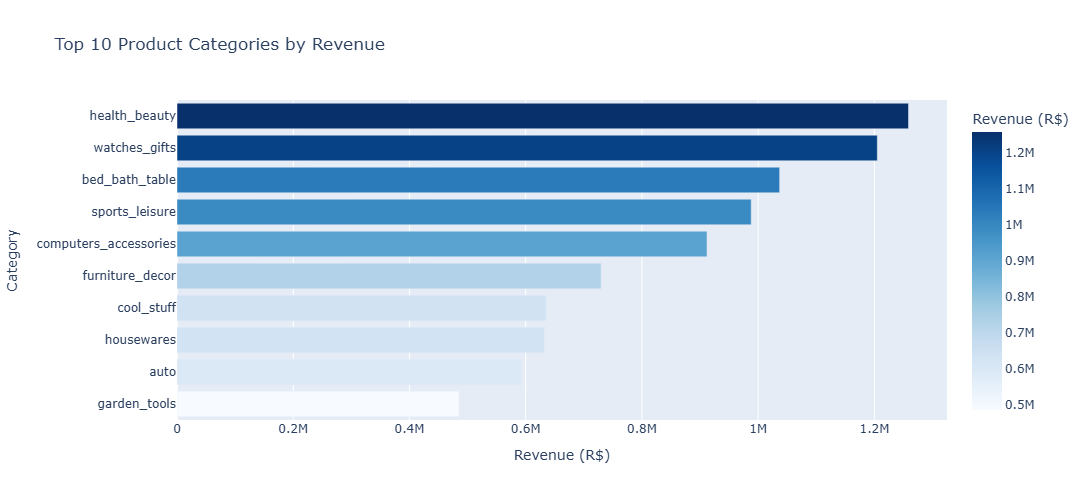

In [46]:
#---- 1. REVENUE BY CATEGORY (Top 10) ----
category_revenue = (
    df.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig1 = px.bar(
    category_revenue,
    x="price",
    y="product_category_name_english",
    orientation="h",
    title="Top 10 Product Categories by Revenue",
    labels={"price": "Revenue (R$)", "product_category_name_english": "Category"},
    color="price",
    color_continuous_scale="Blues",
    height = 500,
    width = 800
)
fig1.update_layout(yaxis=dict(categoryorder="total ascending"))
fig1.show()

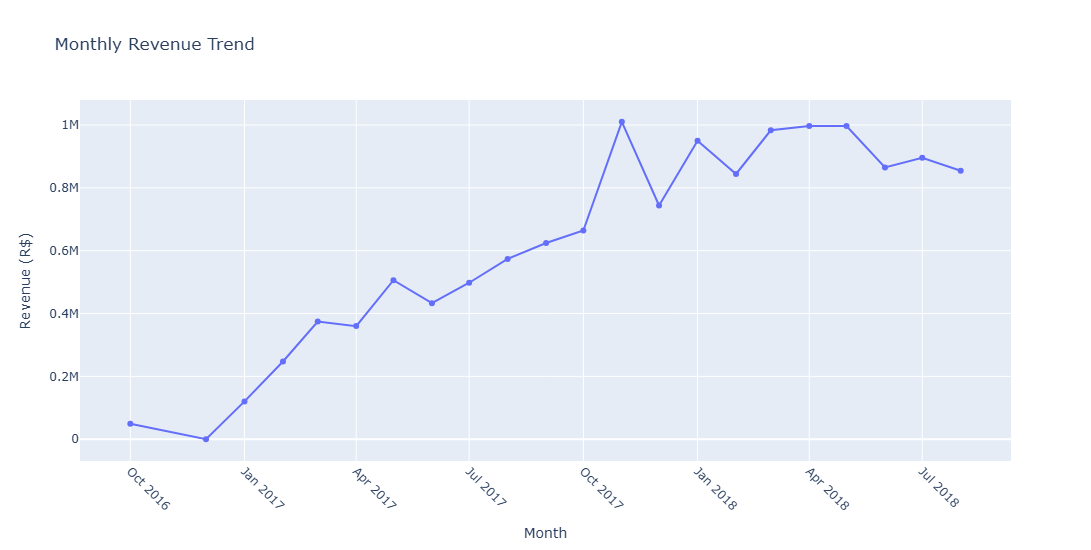

In [48]:
#---- 2. MONTHLY REVENUE TREND ----
# Filter out incomplete edge months (first/last with tiny data)
monthly_revenue = df.groupby(df["order_purchase_timestamp"].dt.to_period("M"))["price"].sum()
monthly_revenue.index = monthly_revenue.index.astype(str)
monthly_revenue = monthly_revenue.reset_index()
monthly_revenue.columns = ["month", "revenue"]

# Optional: exclude first/last partial months
monthly_revenue_clean = monthly_revenue.iloc[1:-1]  # drops 2016-09 and 2018-09 edge rows

fig2 = px.line(
    monthly_revenue_clean,
    x="month",
    y="revenue",
    title="Monthly Revenue Trend",
    markers=True,
    labels={"month": "Month", "revenue": "Revenue (R$)"},
)
fig2.update_xaxes(tickangle=45)
fig2.update_layout(width = 900,height = 550)
fig2.show()

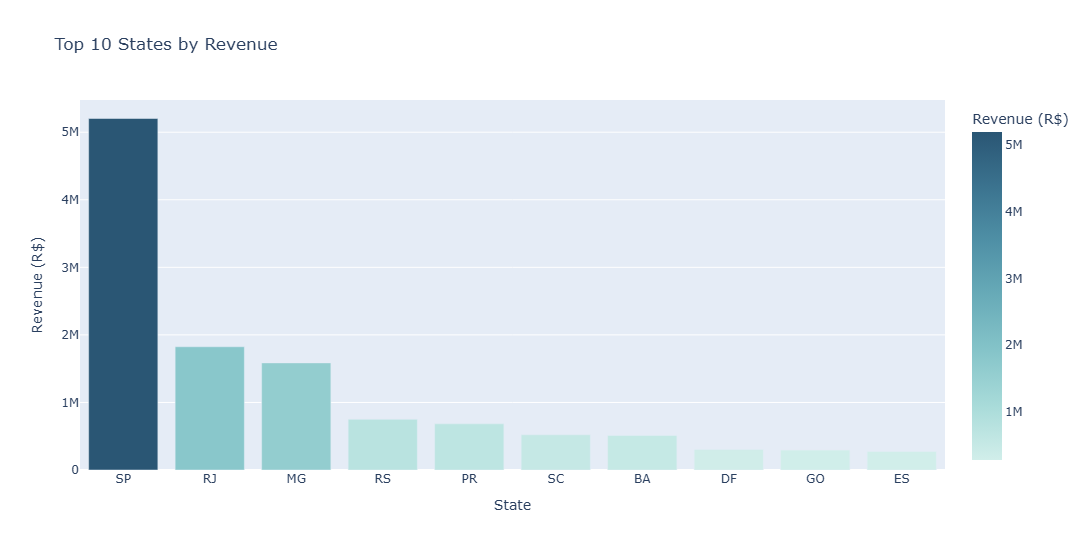

In [50]:
#---- 3. TOP 10 STATES BY REVENUE ----
state_revenue = (
    df.groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig3 = px.bar(
    state_revenue,
    x="customer_state",
    y="price",
    title="Top 10 States by Revenue",
    labels={"customer_state": "State", "price": "Revenue (R$)"},
    color="price",
    color_continuous_scale="Teal",
)
fig3.update_layout(width = 800, height = 550)
fig3.show()

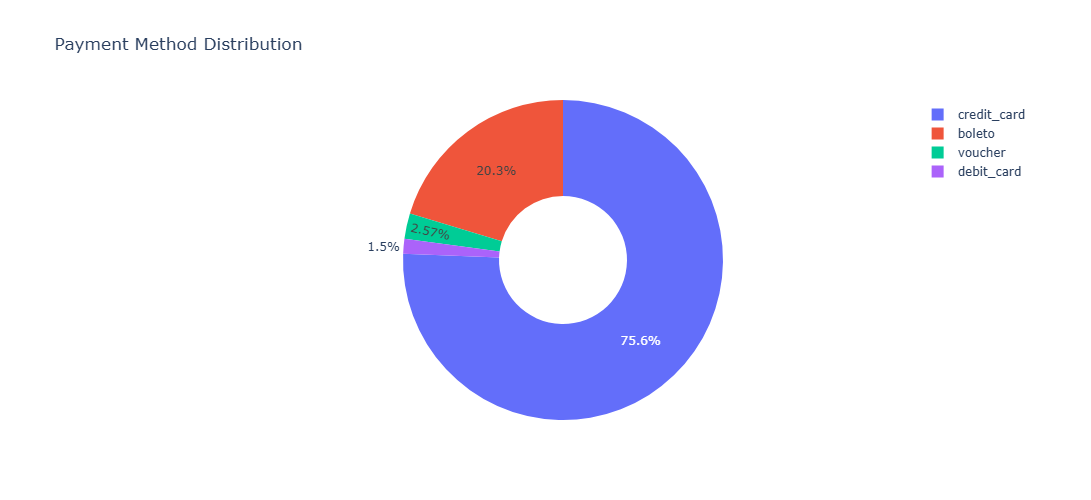

In [51]:
#---- 4. PAYMENT TYPE DISTRIBUTION ----
payment_dist = df["payment_type"].value_counts().reset_index()
payment_dist.columns = ["payment_type", "count"]

fig4 = px.pie(
    payment_dist,
    names="payment_type",
    values="count",
    title="Payment Method Distribution",
    hole=0.4,
)
fig4.update_layout(width = 600, height = 500)
fig4.show()

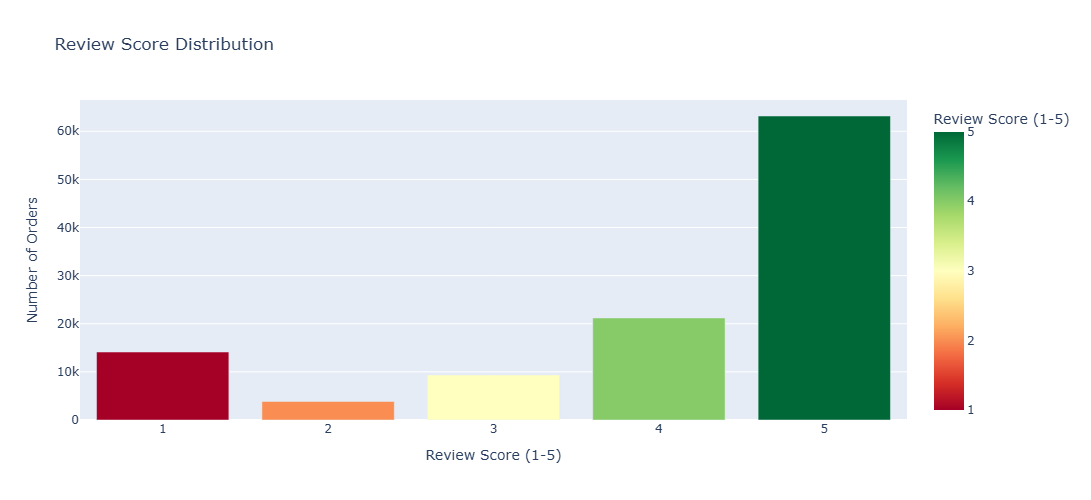

In [52]:
#---- 5. REVIEW SCORE DISTRIBUTION ----
review_dist = df["review_score"].value_counts().sort_index().reset_index()
review_dist.columns = ["review_score", "count"]

fig5 = px.bar(
    review_dist,
    x="review_score",
    y="count",
    title="Review Score Distribution",
    labels={"review_score": "Review Score (1-5)", "count": "Number of Orders"},
    color="review_score",
    color_continuous_scale="RdYlGn",
)
fig5.update_layout(width = 700, height = 500)
fig5.show()

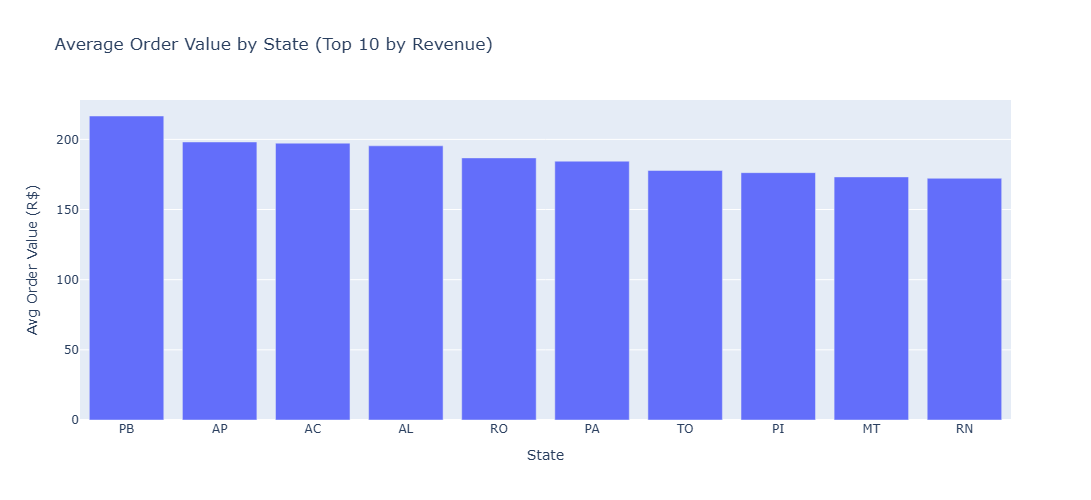

In [54]:
#---- 6. AOV BY STATE (Top 10 by revenue) ----
aov_by_state = (
    df.groupby(["order_id", "customer_state"])["price"]
    .sum()
    .reset_index()
    .groupby("customer_state")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig6 = px.bar(
    aov_by_state,
    x="customer_state",
    y="price",
    title="Average Order Value by State (Top 10 by Revenue)",
    labels={"customer_state": "State", "price": "Avg Order Value (R$)"},
)
fig6.update_layout(width = 800, height = 500)
fig6.show()

## Conclusion

### Overview
This project analyzed the Olist Brazilian e-commerce dataset (2016–2018) by merging orders, order items, customers, products, sellers, payments, and reviews into a single cleaned master table (`ecommerce_master_cleaned.csv`), then explored revenue, geography, seasonality, payments, and customer satisfaction.

### Key Findings
- **Revenue & scale:** The dataset covers ~99K orders with an overall Average Order Value (AOV) of **R$ 137.75**.
- **Top categories:** `health_beauty` (R$ 1.26M) and `watches_gifts` (R$ 1.21M) led product category revenue, followed by `bed_bath_table`, `sports_leisure`, and `computers_accessories` — together the top 5 categories account for a large share of total sales.
- **Geographic concentration:** Revenue is heavily concentrated in the Southeast — **São Paulo (SP)** alone generated **R$ 5.20M**, more than double the next state, **Rio de Janeiro (R$ 1.82M)**, followed by **Minas Gerais (R$ 1.59M)**. The remaining top-10 states each contributed well under R$1M, showing a long tail after the top 3.
- **Seasonality:** Monthly revenue grew steadily from late 2016 through 2018, with a sharp spike in **November 2017 (R$ 1.01M)** — roughly 50% higher than the surrounding months (Oct: R$664K, Dec: R$744K) — consistent with a Black Friday effect.
- **Payments & satisfaction:** Payment method distribution and review score distribution were explored to understand how customers pay and how satisfied they are, adding a customer-experience dimension alongside the revenue analysis.

### Limitations
- The first (2016-09) and last (2018-09) months contain only partial data and were excluded from the trend analysis to avoid misleading dips.
- Revenue figures are based on item `price` and do not include freight cost, so total order value (price + freight) may differ from the revenue totals shown here.
- The dataset ends mid-2018, so no post-2018 trends can be inferred.

### Next Steps
- Incorporate delivery time and freight cost into the analysis to see their effect on review scores.
- Segment AOV and category preferences by state to identify regional buying patterns.
- Build a repeat-customer / retention view, since this dataset primarily supports one-time transaction analysis.
